In [2]:
# --- Libraries ---
import pandas as pd
import numpy as np

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
import seaborn as sns


import os 

# --- Configuration ---
os.chdir(r"C:\Users\Alejandro\Documents\MQuEA\TFM\data")


import aux

# Analisis de los posibles regresores

## Regresor: Geopolitical Risk Index, GPR (Iacovello)

El GPR no es estacionario en niveles, pero su diferencia regular si es estacionaria al 0.1 de confianza

In [5]:
monthly_gpr = pd.read_excel(r"gpr.xlsx", sheet_name="Monthly GPR")


# Date index formatting
monthly_gpr.set_index("date", inplace=True)
monthly_gpr.index = pd.to_datetime(monthly_gpr.index)

spain_gpr = monthly_gpr["GPRC_ESP"].dropna()
spain_hgrp = monthly_gpr["GPRHC_ESP"].dropna()

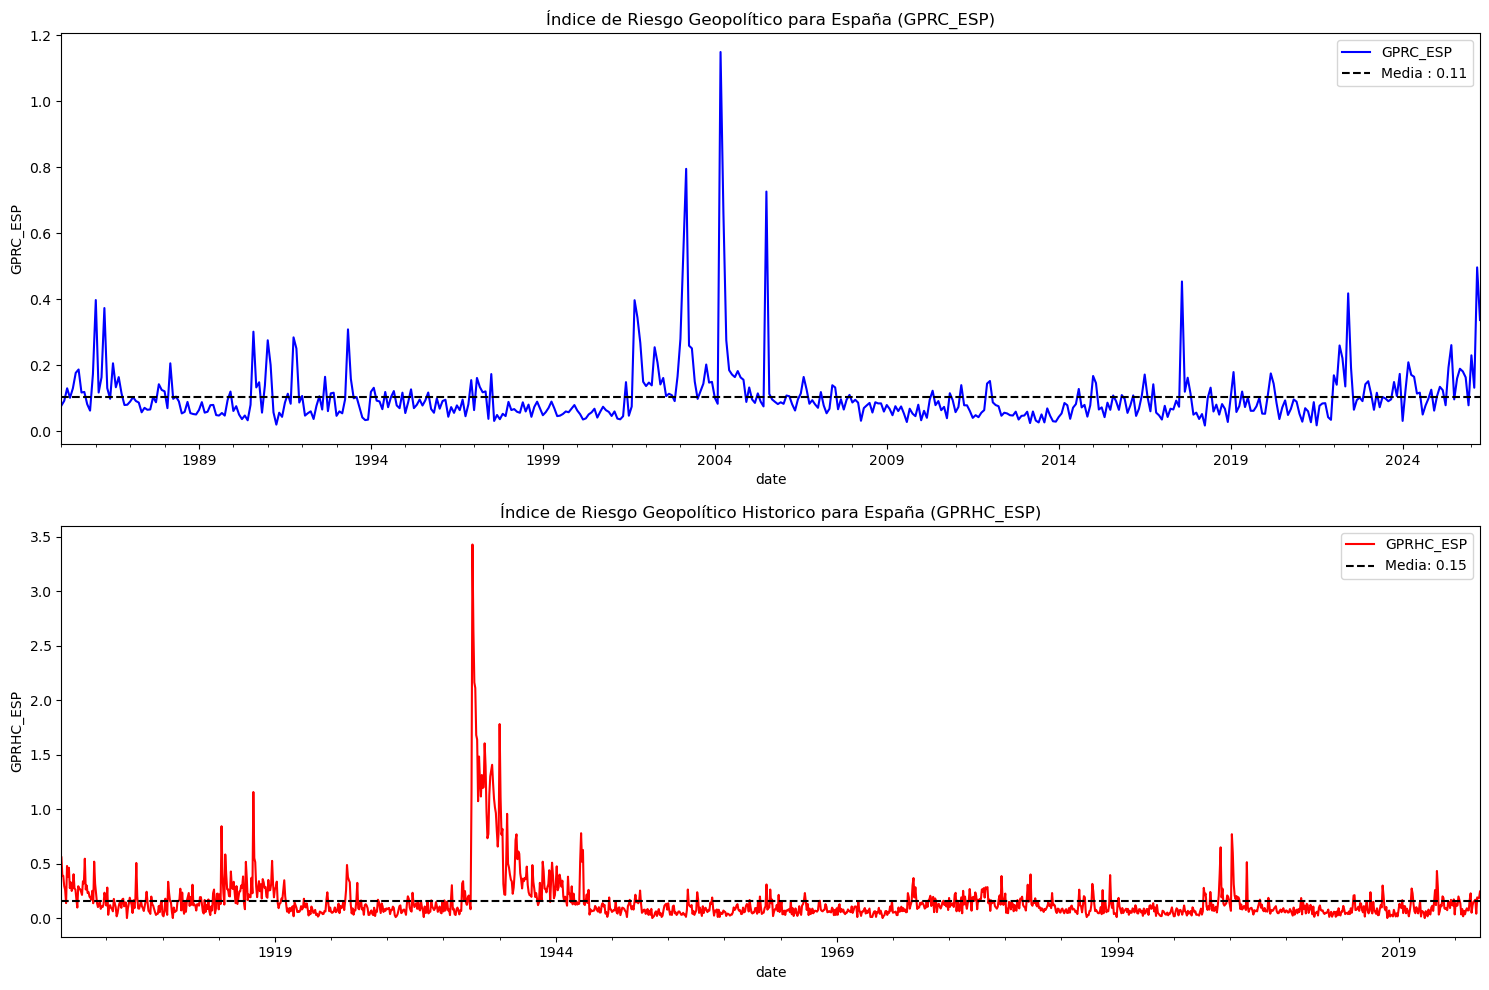

In [6]:
# Ploting the GPR for Spain

fig, ax = plt.subplots(2,1, figsize=(15,10))
spain_gpr.plot(ax=ax[0], title="Índice de Riesgo Geopolítico para España (GPRC_ESP)", color="blue")
ax[0].set_ylabel("GPRC_ESP")
ax[0].hlines(y=spain_gpr.mean(), xmin = spain_gpr.index[0], xmax = spain_gpr.index[-1], color='black', linestyle='--', label='Media : {:.2f}'.format(spain_gpr.mean()))

spain_hgrp.plot(ax=ax[1], title="Índice de Riesgo Geopolítico Historico para España (GPRHC_ESP)", color="red")
ax[1].set_ylabel("GPRHC_ESP")
ax[1].hlines(y=spain_hgrp.mean(), xmin = spain_hgrp.index[0], xmax = spain_hgrp.index[-1], color='black', linestyle='--', label='Media: {:.2f}'.format(spain_hgrp.mean()))

ax[0].legend()
ax[1].legend()
plt.tight_layout()

In [7]:
# Series in levels are not stationary, but their first differences are.
adfuller_result = adfuller(monthly_gpr["GPRC_ESP"].dropna())
print("ADF Test P-value on the series in level:", adfuller_result[1])

adfuller_d_result = adfuller(monthly_gpr["GPRC_ESP"].diff().dropna())
print("ADF Test P-value on the series in first differences:", adfuller_d_result[1])

ADF Test P-value on the series in level: 0.1198403825324093
ADF Test P-value on the series in first differences: 2.392255736534165e-14


By definition, the Geopolitical Risk has to be stationary by construction. In practice, it is common to work with the logarithm of the GPR to reduce heteroskedasticity on the data.

ADF Test P-value on the series in level: 0.010086237474548995


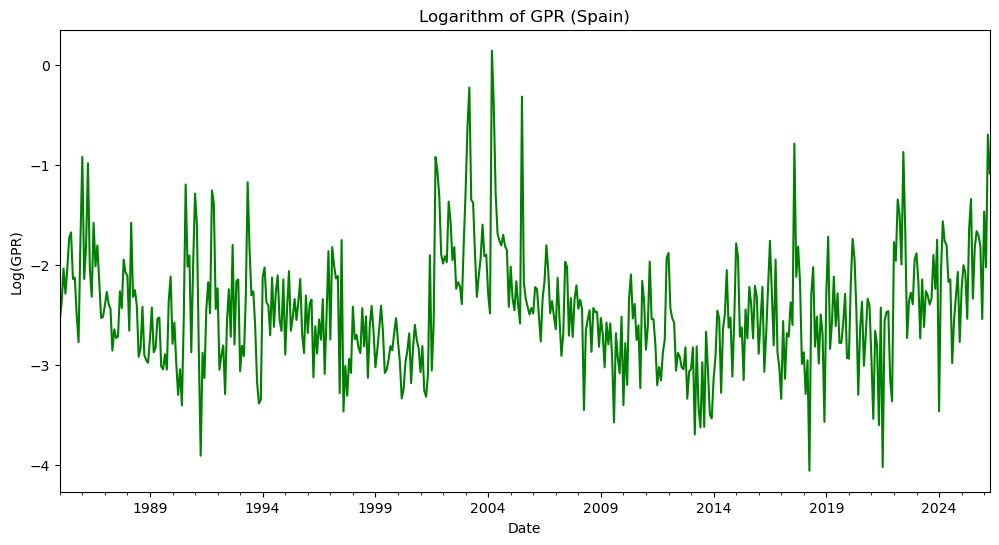

In [12]:
gpr_esp_log = np.log(spain_gpr)

adfuller_result = adfuller(gpr_esp_log.dropna())
print("ADF Test P-value on the series in level:", adfuller_result[1])

gpr_esp_log.plot(figsize=(12, 6), title="Logarithm of GPR (Spain)", color="green")
plt.xlabel("Date")
plt.ylabel("Log(GPR)")
plt.show()

### Extracting shocks from the GPR

<Axes: title={'center': 'Ciclo del GPR_ESP'}, xlabel='date'>

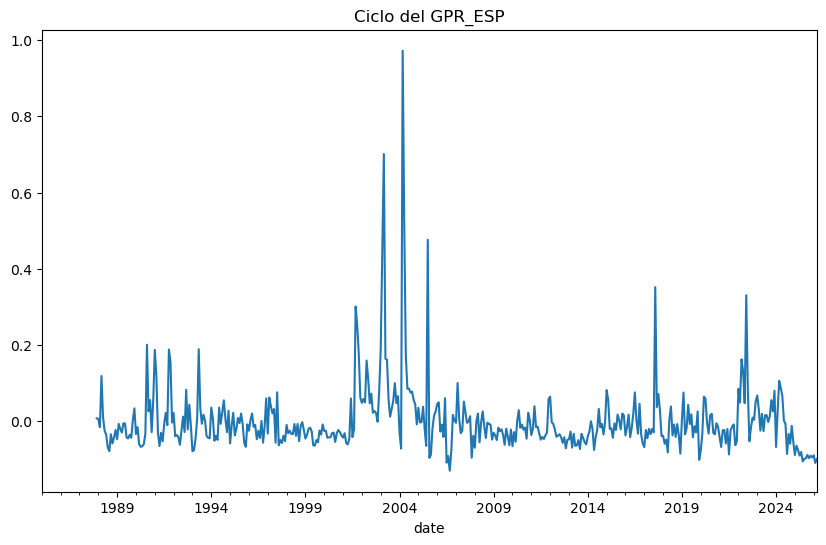

In [ ]:
# Compute the cycle of ESP GPR using the Hamilton Filter

hf_gpr = aux.hamilton_filter(spain_gpr.dropna())
hf_gpr.plot(figsize=(10,6), title = "Ciclo del GPR_ESP")

### Country Level GPR

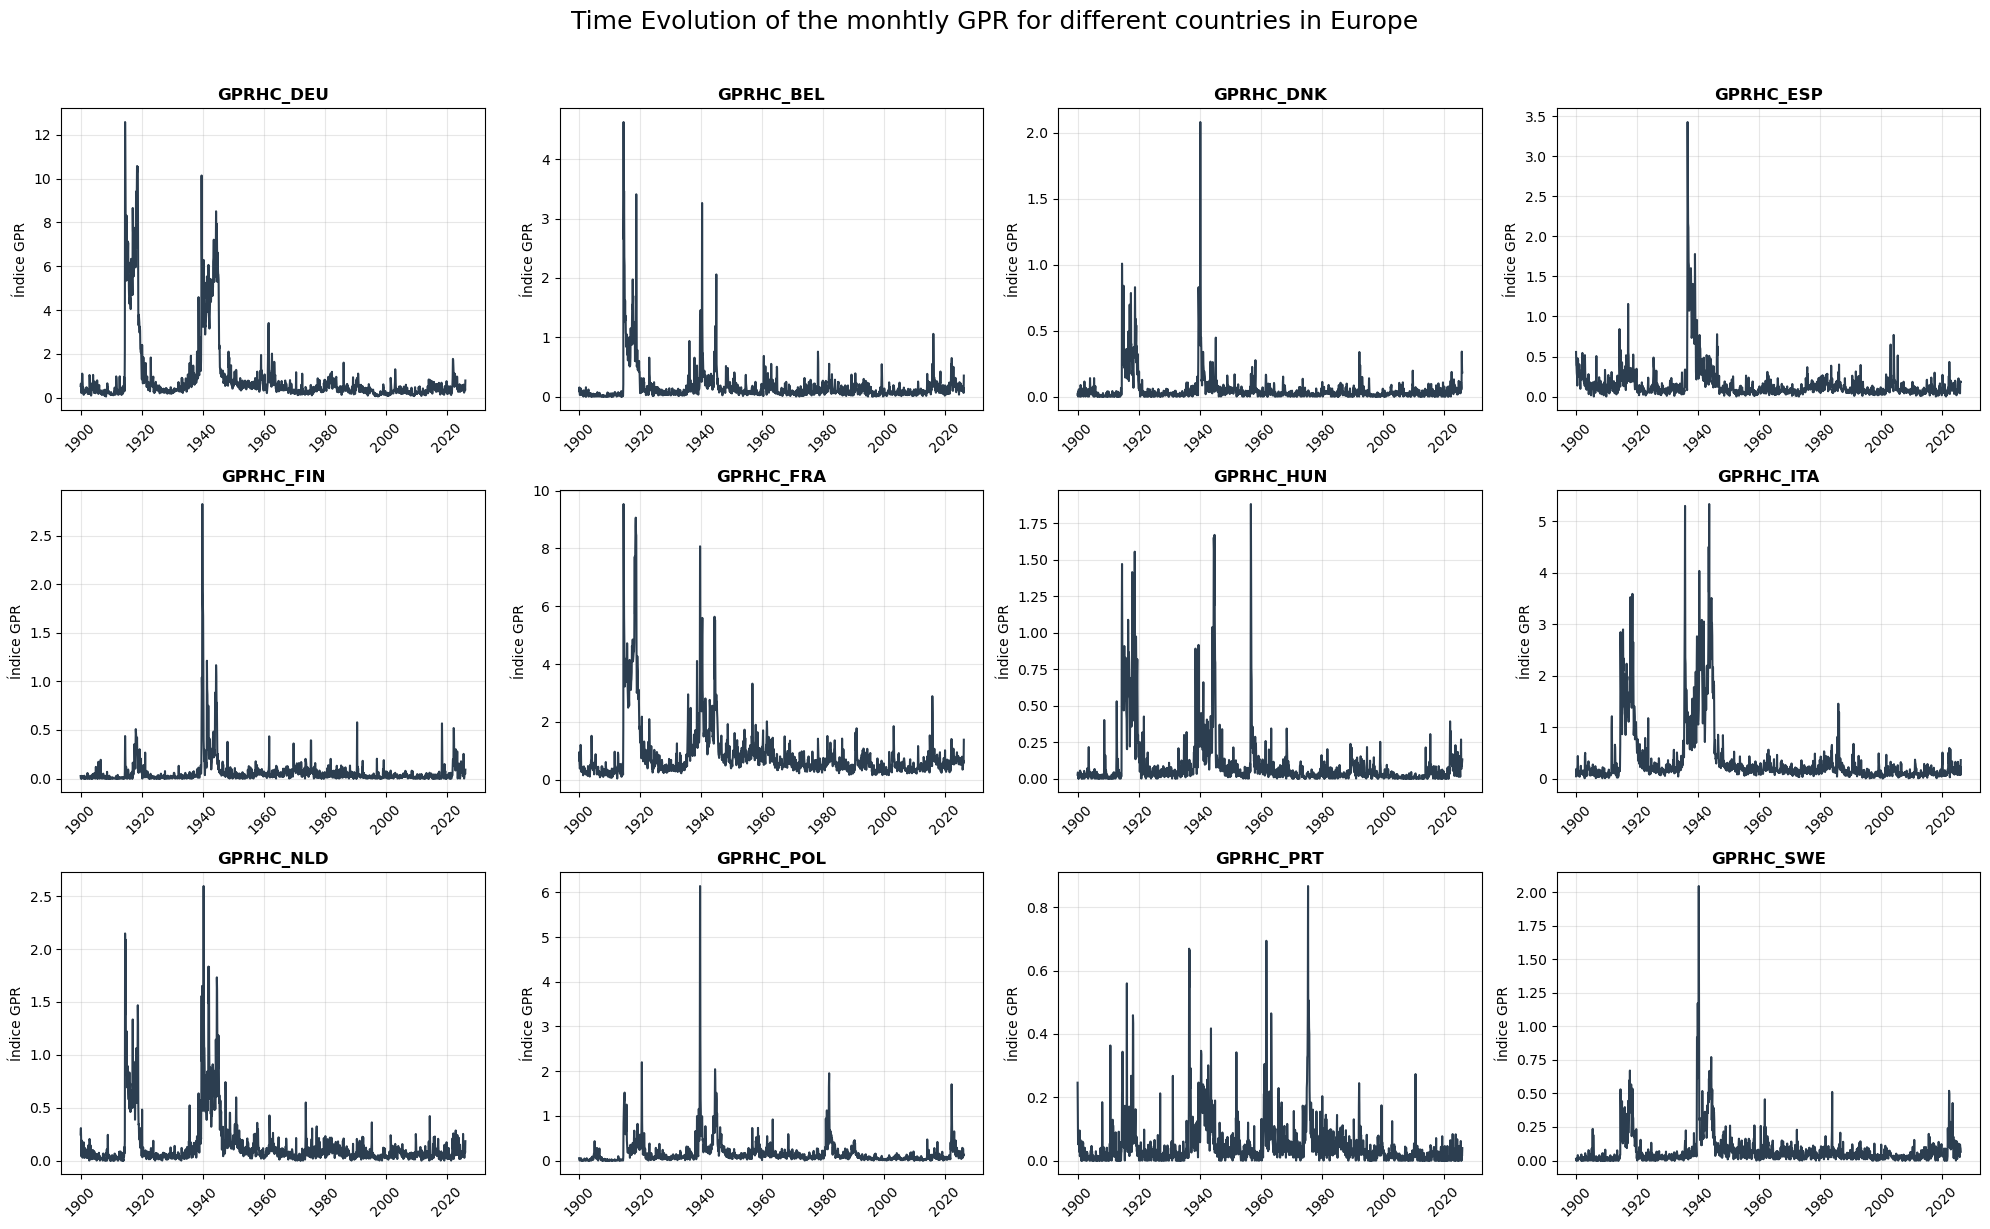

In [ ]:

# Fix: Renamed u_countries to eu_countries to match the filter logic
eu_countries = [
    "GPRHC_DEU",  # Alemania (Germany)
    "GPRHC_AUT",  # Austria (Austria)
    "GPRHC_BEL",  # Bélgica (Belgium)
    "GPRHC_BGR",  # Bulgaria (Bulgaria)
    "GPRHC_CYP",  # Chipre (Cyprus)
    "GPRHC_HRV",  # Croacia (Croatia)
    "GPRHC_DNK",  # Dinamarca (Denmark)
    "GPRHC_SVK",  # Eslovaquia (Slovakia)
    "GPRHC_SVN",  # Eslovenia (Slovenia)
    "GPRHC_ESP",  # España (Spain)
    "GPRHC_EST",  # Estonia (Estonia)
    "GPRHC_FIN",  # Finlandia (Finland)
    "GPRHC_FRA",  # Francia (France)
    "GPRHC_GRC",  # Grecia (Greece)
    "GPRHC_HUN",  # Hungría (Hungary)
    "GPRHC_IRL",  # Irlanda (Ireland)
    "GPRHC_ITA",  # Italia (Italy)
    "GPRHC_LVA",  # Letonia (Latvia)
    "GPRHC_LTU",  # Lituania (Lithuania)
    "GPRHC_LUX",  # Luxemburgo (Luxembourg)
    "GPRHC_MLT",  # Malta (Malta)
    "GPRHC_NLD",  # Países Bajos (Netherlands)
    "GPRHC_POL",  # Polonia (Poland)
    "GPRHC_PRT",  # Portugal (Portugal)
    "GPRHC_CZE",  # República Checa (Czech Republic)
    "GPRHC_ROU",  # Rumanía (Romania)
    "GPRHC_SWE"   # Suecia (Sweden)
]

# Filtramos la lista para quedarnos solo con los que están en las columnas
paises_existentes = [pais for pais in eu_countries if pais in monthly_gpr.columns]

# Seleccionamos los países, eliminamos NAs, y mantenemos el índice (que contiene las fechas)
gpr_eu = monthly_gpr[paises_existentes].dropna().copy()

# --- Configuración de la cuadrícula ---
columnas = 4 
filas = (len(paises_existentes) + columnas - 1) // columnas 

# Creamos la figura y los "Ejes" (subplots)
fig, axes = plt.subplots(filas, columnas, figsize=(5 * columnas, 4 * filas))
axes = axes.flatten() 

# Creamos cada lineplot con un bucle
for i, pais in enumerate(paises_existentes):
    sns.lineplot(
        data=gpr_eu,          
        x=gpr_eu.index, # El eje X es el índice (las fechas)
        y=pais,         # El eje Y es el valor del GPR para ese país
        ax=axes[i],
        color="#2c3e50",
        linewidth=1.5
    )
    
    # Mejoras estéticas para cada subgráfico
    axes[i].set_title(pais, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("") # Quitamos la etiqueta 'x' para que no sature
    axes[i].set_ylabel("Índice GPR")
    axes[i].tick_params(axis='x', rotation=45) # Rotamos las fechas
    axes[i].grid(alpha=0.3)

# Borramos los espacios sobrantes si la cuadrícula es más grande que el número de países
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Título general
fig.suptitle("Time Evolution of the monhtly GPR for different countries in Europe", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## Regresor: Economic Policy Uncertainty (BdE)

Existen otros indices de riesgo geopolítico. Por ejemplo, el BdE ofrece el EPU (Economic Policy Uncertainty), basado en 7 periodos nacionales. El  indice mide el ratio de noticias negativas entre el total de noticias consideradas, y lo normaliza para que su media histótica sea 100. El resultado es un índice mensual con datos desde 1997.

In [ ]:
epu = pd.read_excel(r"epu.xlsx")

# Creating the data column and setting it as index
epu["date"] = epu["Year"].astype(str) + "-" + epu["Month"].astype(int).astype(str).str.zfill(2)
epu["date"] = pd.to_datetime(epu["date"], format="%Y-%m")

# Setting the date as the index
epu.set_index(epu["date"], inplace=True)
 
#Unnecesary columns
epu.drop(columns = ["Year", "Month", "date"], inplace = True)

In [ ]:
epu.columns

Index(['GEPU_current', 'GEPU_ppp', 'Australia', 'Brazil', 'Canada', 'Chile',
       'China', 'France', 'Germany', 'Greece', 'India', 'Ireland', 'Italy',
       'Japan', 'Korea', 'Pakistan', 'Russia', 'Spain', 'Singapore', 'UK',
       'US', 'SCMP China', 'Mainland China', 'Sweden', 'Mexico'],
      dtype='object')

<Axes: title={'center': 'EPU for Spain'}, xlabel='Date'>

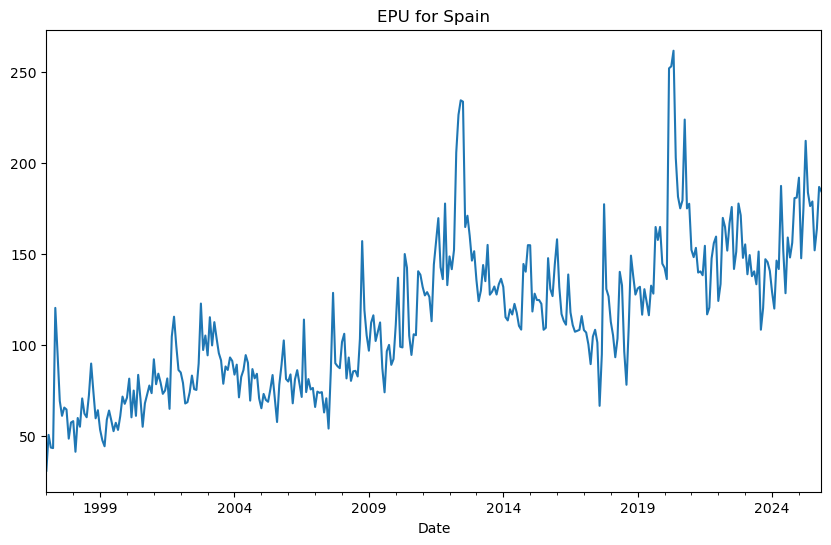

In [ ]:
epu["Spain"].dropna().plot(title="EPU for Spain", figsize=(10,6))

<Axes: title={'center': '1st difference of EPU for Spain'}, xlabel='Date'>

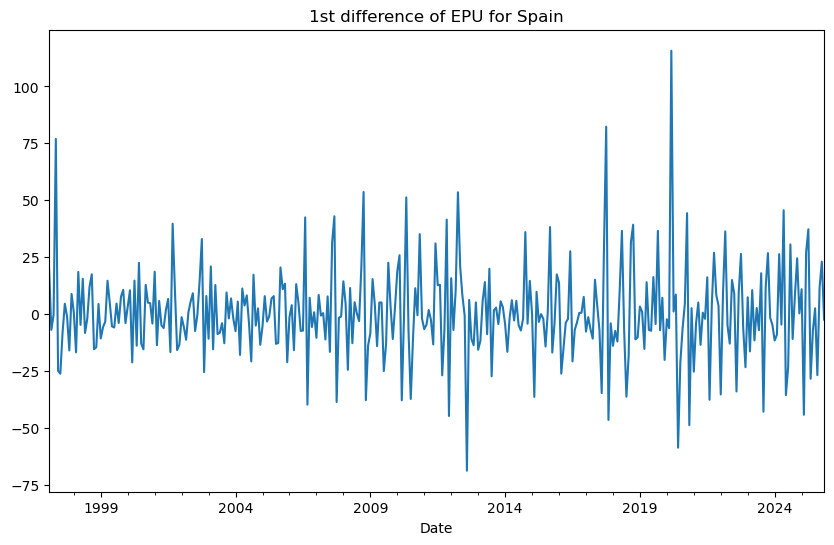

In [ ]:
epu["Spain"].diff().dropna().plot(title="1st difference of EPU for Spain", figsize=(10,6))

<Axes: title={'center': '1st difference of the Log of  EPU for Spain'}, xlabel='Date'>

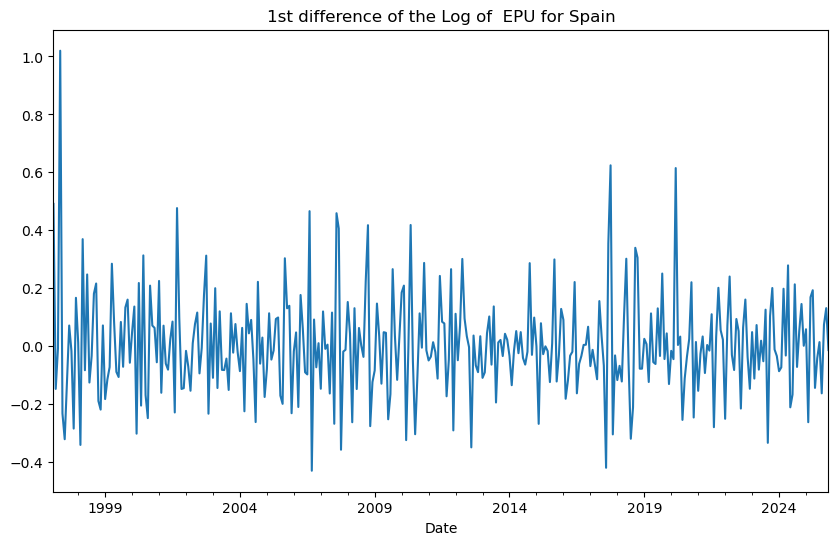

In [ ]:
np.log(epu["Spain"]).diff().dropna().plot(title="1st difference of the Log of  EPU for Spain", figsize=(10,6))

In [ ]:
epu_ld = np.log(epu).diff().dropna()
epu_ld.to_csv("epu_ld.csv")